# Sequence to Sequence 翻译项目：英语-日语

## 深度学习项目启动配置

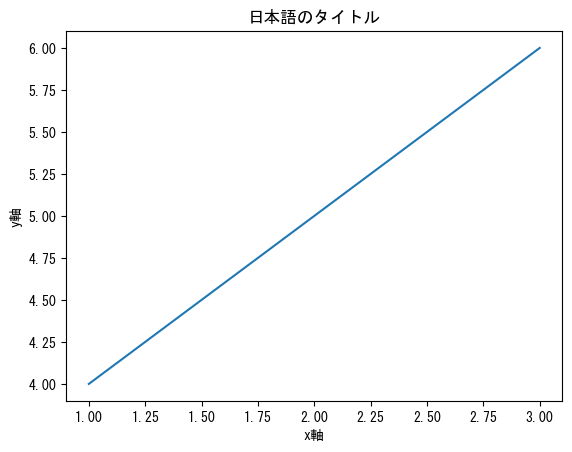

sys.version_info(major=3, minor=12, micro=2, releaselevel='final', serial=0)
matplotlib 3.9.0
numpy 1.26.4
torch 2.5.1+cu121
cuda:0


In [33]:
import matplotlib as mpl
import matplotlib.pyplot as plt
# 绘图结果直接显示在笔记本文档中，而不是弹出一个独立的窗口
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import os
import sys
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F

# 配置matplotlib支持日语字符显示
# Windows系统可以使用 'MS Gothic' 或 'Yu Gothic'
# Linux/Mac可以使用 'Noto Sans CJK JP' 或 'Hiragino Sans'
# 尝试使用Windows系统字体
plt.rcParams['font.sans-serif'] = ['MS Gothic', 'Yu Gothic', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 环境版本检查与硬件检测
print(sys.version_info)
for module in mpl, np, torch:
    print(module.__name__, module.__version__)

device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)

# 随机种子设置保证可复现性
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)

## 数据加载

In [ ]:
from janome.tokenizer import Tokenizer # 导入日语分词工具
import re

# 初始化日语分词器
tokenizer_ja = Tokenizer()

def preprocess_ja(w):
    """
    预处理日语句子，去除首尾空格，分词，清洗非日语/非必要字符，合并多余空格
    """
    # 1. 去除首尾空格
    w = w.strip()
    # 2. 分词：将 "本を借りてもいいですか？" 变为 "本 を 借り て も いい です か ？"
    # Janome 会自动处理日语中的全角标点
    # 使用 wakati 模式进行分词，这样可以保留标点符号
    tokens = tokenizer_ja.tokenize(w, wakati=True)
    w = " ".join(tokens)
    
    # 3. 清洗非日语/非必要字符（可选）
    # 这里保留汉字 (\u4e00-\u9fa5)、平假名 (\u3040-\u309f)、片假名 (\u30a0-\u30ff)
    # 以及常见的全角/半角标点
    w = re.sub(r"[^ \u4e00-\u9fa5\u3040-\u309f\u30a0-\u30ff?.!,。！？]+", " ", w)
    
    # 4. 合并多余空格
    w = re.sub(r'[" "]+', " ", w).strip()
    return w

def preprocess_en(w):
    """
    预处理英语句子，去除首尾空格，清洗非英语/非必要字符，合并多余空格
    """
    # 1. 转小写并去除首尾空格
    w = w.lower().strip()
    # 2. 在标点符号前后加空格
    w = re.sub(r"([?.!,])", r" \1 ", w)
    # 3. 除了字母和基本标点，其余替换为空格
    w = re.sub(r"[^a-zA-Z?.!,]+", " ", w)
    # 4. 合并多余空格
    w = re.sub(r'[" "]+', " ", w).strip()
    return w

In [3]:
# 测试样本
en_sample = u"May I borrow this book?"
ja_sample = u"本を借りてもいいですか？"

print(preprocess_en(en_sample))
print(preprocess_ja(ja_sample))

may i borrow this book ?
本 を 借り て も いい です か ？


In [4]:
!wc -l data_en_ja/jpn.txt

117022 data_en_ja/jpn.txt


In [5]:
# 统计数据行数
file_path = 'data_en_ja/jpn.txt'

try:
    with open(file_path, 'r', encoding='utf-8') as f:
        # 使用生成器高效统计行数，不会占用过多内存
        line_count = sum(1 for line in f)
        print(f"文件 {file_path} 总行数: {line_count}")
except FileNotFoundError:
    print(f"错误：未找到文件，请检查路径是否正确。")
except Exception as e:
    print(f"发生错误: {e}")

文件 data_en_ja/jpn.txt 总行数: 117022


## Dataset

**注意代码修改后需将旧缓存删除再重新运行，否则可能出现问题！**

In [6]:
from pathlib import Path
from torch.utils.data import Dataset, DataLoader

class LangPairDataset(Dataset):
    """
    自定义数据集类，用于处理语言对数据
    """
    fpath = Path(r"./data_en_ja/jpn.txt")  #数据文件路径
    cache_path = Path(r"./.cache/lang_pair.npy")  #缓存文件路径
    split_index = np.random.choice(a=["train", "test"], replace=True, p=[0.9, 0.1], size=line_count)  #按照9:1随机抽取划分训练集和测试集

    def __init__(self, mode="train", cache=False):
        if cache or not self.cache_path.exists():  #如果没有缓存，或者缓存不存在，就处理一下数据
            self.cache_path.parent.mkdir(parents=True, exist_ok=True)  #创建缓存文件夹，如果存在就忽略
            with open(self.fpath, "r", encoding="utf8") as file:
                lines = file.readlines()  # 读取数据
                lang_pair = []
                for line in lines:  #处理数据，变成list((trg, src))的形式
                    en, ja, _ = line.split('\t')
                    lang_pair.append([preprocess_en(en), preprocess_ja(ja)])
                trg, src = zip(*lang_pair)  #分离出目标语言和源语言,如果要让英语作为src，把这里交换位置即可
                trg=np.array(trg) #转换为numpy数组
                src=np.array(src) #转换为numpy数组
                np.save(self.cache_path, {"trg": trg, "src": src})  #保存为npy文件,方便下次直接读取,不用再处理
        else:
            lang_pair = np.load(self.cache_path, allow_pickle=True).item() #读取npy文件，allow_pickle=True允许读取字典
            trg = lang_pair["trg"]
            src = lang_pair["src"]

        self.trg = trg[self.split_index == mode] #按照index拿到训练集的 标签语言 --英语
        self.src = src[self.split_index == mode] #按照index拿到训练集的源语言 --日语

    def __getitem__(self, index):
        return self.src[index], self.trg[index]

    def __len__(self):
        return len(self.src)


train_ds = LangPairDataset("train")
test_ds = LangPairDataset("test")

In [7]:
# 查看数据集处理结果
print(len(train_ds))
print(len(test_ds))
print("训练集最后一个样本：\n", "source: {}\ntarget: {}".format(*train_ds[-1]))
print("测试集最后一个样本：\n", "source: {}\ntarget: {}".format(*test_ds[-1]))

105512
11510
训练集最后一个样本：
 source: 彼氏 の 友達 と 飲み に 行っ たら 彼 に 激怒 さ れ ちゃっ た その 友達 って 男 ？ 女 ？ 男 に 決まっ てる でしょ 。 どうして 彼氏 の 女 友達 と 飲み に 行か なきゃ いけ ない の ？ そりゃ そう だ 彼 ね トム って 言う ん だ けど めっちゃ イケ てる の 。 また 行き たい な
target: i went drinking with one of my boyfriend s friends , and now he s furious at me . was this friend a guy or a girl ? a guy , obviously . why would i go drinking with his female friends ? yeah , you re right . his name is tom . he s really hot , and i really want to go drinking with him again .
测试集最后一个样本：
 source: アンケート に お答え いただい た 方 の 中 から 毎月 抽選 で 名 様 に 万 円 分 の 商品 券 を プレゼント いたし ます 。
target: each month , a gift certificate worth , yen will be given to thirty people chosen at random who have completed this questionnaire .


## 构建词表

In [8]:
from collections import Counter

# 设置特殊token ID
pad_idx = 0
bos_idx = 1
unk_idx = 2
eos_idx = 3

def get_word_idx(ds, mode="src", threshold=2):
    """
    词表创建
    """
    # 添加特殊 token
    word2idx = {
        "[PAD]": pad_idx,     # 填充 token
        "[BOS]": bos_idx,     # begin of sentence
        "[UNK]": unk_idx,     # 未知 token
        "[EOS]": eos_idx,     # end of sentence
    }
    idx2word = {value: key for key, value in word2idx.items()}
    
    index = len(idx2word)
    threshold = 1  # 出现次数低于此的token舍弃
    #太大不要都放入到内存，避免爆掉，word_list是训练集所有的词，变为一个列表，列表里每个元素都是一个词
    word_list = " ".join([pair[0 if mode=="src" else 1] for pair in ds]).split()
    # print(type(word_list))

    # 统计词频,counter类似字典，key是单词，value是出现次数
    counter = Counter(word_list) 
    # print("word count:", len(counter))

    for token, count in counter.items():
        if count >= threshold:  # 出现次数大于阈值的token加入词表
            word2idx[token] = index  # 加入词表
            idx2word[index] = token  # 加入反向词表
            index += 1

    return word2idx, idx2word

src_word2idx, src_idx2word = get_word_idx(train_ds, "src")  #源语言词表  日语
trg_word2idx, trg_idx2word = get_word_idx(train_ds, "trg")  #目标语言词表 英语



In [9]:
# 查看正反向词表长度是否相等
print(len(src_word2idx))
print(len(src_idx2word))
print(len(trg_word2idx))
print(len(trg_idx2word))

18183
18183
11217
11217


## Tokenizer

这里有两种处理方式，分别对应着 encoder 和 decoder 的 word embedding 是否共享，这里实现不共享的方案。

In [10]:
class Tokenizer:
    def __init__(self, word2idx, idx2word, max_length=500, pad_idx=pad_idx, bos_idx=bos_idx, eos_idx=eos_idx, unk_idx=unk_idx):
        self.word2idx = word2idx
        self.idx2word = idx2word
        self.max_length = max_length
        self.pad_idx = pad_idx
        self.bos_idx = bos_idx
        self.eos_idx = eos_idx
        self.unk_idx = unk_idx

    def encode(self, text_list, padding_first=False, add_bos=True, add_eos=True, return_mask=False):
        """
        text_list是一个二维列表，里边的每一个元素是一个样本，样本里边是词的列表
        如果padding_first == True，则padding加载前面，否则加载后面
        return_mask: 是否返回mask(掩码），mask用于指示哪些是padding的，哪些是真实的token
        """
        max_length = min(self.max_length, add_eos + add_bos + max([len(text) for text in text_list]))
        indices_list = []
        for text in text_list:
            indices = [self.word2idx.get(word, self.unk_idx) for word in text[:max_length - add_bos - add_eos]] #如果词表中没有这个词，就用unk_idx代替，indices是一个list,里面是每个词的index,也就是一个样本的index
            if add_bos:
                indices = [self.bos_idx] + indices #添加开头
            if add_eos:
                indices = indices + [self.eos_idx] #添加结尾
            if padding_first:#padding加载前面，超参可以调
                indices = [self.pad_idx] * (max_length - len(indices)) + indices #padding加载前面
            else:#padding加载后面
                indices = indices + [self.pad_idx] * (max_length - len(indices)) #padding加载后面
            indices_list.append(indices)
        input_ids = torch.tensor(indices_list) #转换为tensor
        masks = (input_ids == self.pad_idx).to(dtype=torch.int64) #mask是一个和input_ids一样大小的tensor，0代表token，1代表padding，mask用于去除padding的影响
        return input_ids if not return_mask else (input_ids, masks)


    def decode(self, indices_list, remove_bos=True, remove_eos=True, remove_pad=True, split=False):
        """
        indices_list是一个二维列表，里边的每一个元素是一个样本，样本里边是词的index
        remove_bos: 是否去除开头
        remove_eos: 是否去除结尾
        remove_pad: 是否去除padding
        split: 是否把列表中的单词拼接，变为一个句子
        """
        text_list = []
        for indices in indices_list:
            text = []
            for index in indices:
                word = self.idx2word.get(index, "[UNK]") #如果词表中没有这个词，就用unk_idx代替
                if remove_bos and word == "[BOS]":
                    continue
                if remove_eos and word == "[EOS]":#如果到达eos，就结束
                    break
                if remove_pad and word == "[PAD]":#如果到达pad，就结束
                    break
                text.append(word) #单词添加到列表中
            #把列表中的单词拼接，变为一个句子,split=True时，返回列表，split=False时，返回句子，返回列表的目的是为了画注意力的热力图 
            text_list.append(" ".join(text) if not split else text) 
        return text_list

#两个toknizer 相对于1个toknizer的好处是embedding的参数量减少
src_tokenizer = Tokenizer(word2idx=src_word2idx, idx2word=src_idx2word) #源语言tokenizer
trg_tokenizer = Tokenizer(word2idx=trg_word2idx, idx2word=trg_idx2word) #目标语言tokenizer

In [11]:
# trg_tokenizer.encode([["hello"], ["hello", "world"]], add_bos=True, add_eos=False,return_mask=True)
raw_text = ["hello world".split(), "Well play it by ear".split(), "this is a test".split()]
indices,mask = trg_tokenizer.encode(raw_text, padding_first=False, add_bos=True, add_eos=True,return_mask=True)

print("raw text"+'-'*10)
for raw in raw_text:
    print(raw)
print("mask"+'-'*10)
for m in mask:
    print(m)
print("indices"+'-'*10)
for index in indices:
    print(index)

raw text----------
['hello', 'world']
['Well', 'play', 'it', 'by', 'ear']
['this', 'is', 'a', 'test']
mask----------
tensor([0, 0, 0, 0, 1, 1, 1])
tensor([0, 0, 0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0, 0, 1])
indices----------
tensor([   1,   20, 2079,    3,    0,    0,    0])
tensor([   1,    2,  425,   33, 1046, 4205,    3])
tensor([   1,  124,  209,  114, 1964,    3,    0])


## DataLoader

In [12]:
def collate_fct(batch):
    src_words = [pair[0].split() for pair in batch] #取batch内第0列进行分词，赋给src_words
    trg_words = [pair[1].split() for pair in batch] #取batch内第1列进行分词，赋给trg_words

    # [PAD] [BOS] src [EOS]
    encoder_inputs, encoder_inputs_mask = src_tokenizer.encode(
        src_words, padding_first=True, add_bos=True, add_eos=True, return_mask=True
        )

    # [BOS] trg [PAD]
    decoder_inputs = trg_tokenizer.encode(
        trg_words, padding_first=False, add_bos=True, add_eos=False, return_mask=False,
        )

    # trg [EOS] [PAD]
    decoder_labels, decoder_labels_mask = trg_tokenizer.encode(
        trg_words, padding_first=False, add_bos=False, add_eos=True, return_mask=True
        )

    return {
        "encoder_inputs": encoder_inputs.to(device=device),
        "encoder_inputs_mask": encoder_inputs_mask.to(device=device),
        "decoder_inputs": decoder_inputs.to(device=device),
        "decoder_labels": decoder_labels.to(device=device),
        "decoder_labels_mask": decoder_labels_mask.to(device=device), #mask用于去除padding的影响，计算loss时用
    } #当返回的tensor较多时，用dict返回比较合理


In [13]:
sample_dl = DataLoader(train_ds, batch_size=2, shuffle=True, collate_fn=collate_fct)

#两次执行这个代码效果不一样，因为每次执行都会shuffle
for batch in sample_dl:
    for key, value in batch.items():
        print(key)
        print(value)
        print('-'*50)
    break

encoder_inputs
tensor([[   0,    0,    0,    0,    0,    0,    0,    1, 4185,   74,  720,   68,
           16,    3],
        [   1, 2734,   74,  155,   68,   76,  351, 2612,  133,   59,   25,   42,
            5,    3]], device='cuda:0')
--------------------------------------------------
encoder_inputs_mask
tensor([[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], device='cuda:0')
--------------------------------------------------
decoder_inputs
tensor([[   1,  325,   97,  391,  272, 2336,    9,    0,    0,    0],
        [   1,  348,  892, 1697,   26,  122,  165,   46,  240,    5]],
       device='cuda:0')
--------------------------------------------------
decoder_labels
tensor([[ 325,   97,  391,  272, 2336,    9,    3,    0,    0,    0],
        [ 348,  892, 1697,   26,  122,  165,   46,  240,    5,    3]],
       device='cuda:0')
--------------------------------------------------
decoder_labels_mask
tensor([[0, 0, 0, 0, 0, 0, 0, 1, 1,

## 模型定义

In [14]:
class Encoder(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim=256,
        hidden_dim=1024,
        num_layers=1,
        ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.gru = nn.GRU(embedding_dim, hidden_dim, num_layers=num_layers, batch_first=True)

    def forward(self, encoder_inputs):
        # encoder_inputs.shape = [batch size, sequence length]
        # bs, seq_len = encoder_inputs.shape
        embeds = self.embedding(encoder_inputs)
        # embeds.shape = [batch size, sequence length, embedding_dim]->[batch size, sequence length, hidden_dim]
        seq_output, hidden = self.gru(embeds)
        # seq_output.shape = [batch size, sequence length, hidden_dim]，hidden.shape [ num_layers, batch size, hidden_dim]
        return seq_output, hidden

In [15]:
#把上面的Encoder写一个例子，看看输出的shape
encoder = Encoder(vocab_size=100, embedding_dim=256, hidden_dim=1024, num_layers=4)
encoder_inputs = torch.randint(0, 100, (2, 50))
encoder_outputs, hidden = encoder(encoder_inputs)
print(encoder_outputs.shape)
print(hidden.shape)
print(encoder_outputs[:,-1,:])
print(hidden[-1,:,:]) #取最后一层的hidden

torch.Size([2, 50, 1024])
torch.Size([4, 2, 1024])
tensor([[-0.0636,  0.0092,  0.0103,  ..., -0.0153, -0.0004, -0.0341],
        [-0.0175,  0.0283,  0.0105,  ...,  0.0142,  0.0282, -0.0413]],
       grad_fn=<SliceBackward0>)
tensor([[-0.0636,  0.0092,  0.0103,  ..., -0.0153, -0.0004, -0.0341],
        [-0.0175,  0.0283,  0.0105,  ...,  0.0142,  0.0282, -0.0413]],
       grad_fn=<SliceBackward0>)


### BahdanauAttention公式
`score = FC(tanh(FC(EO) + FC(H)))` 

>FC(EO)的FC是Wk,FC(H)的FC是Wq,最外面的FC是V 

`attention_weights = softmax(score, axis = 1)`  

`context = sum(attention_weights * EO, axis = 1)` 

>对EO做加权求和，得到上下文向量

In [16]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim=1024):
        super().__init__()
        self.Wk = nn.Linear(hidden_dim, hidden_dim) #对keys做运算，encoder的输出EO
        self.Wq = nn.Linear(hidden_dim, hidden_dim) #对query做运算，decoder的隐藏状态
        self.V = nn.Linear(hidden_dim, 1) #V矩阵

    def forward(self, query, keys, values, attn_mask=None):
        """
        正向传播
        :param query: hidden state，是decoder的隐藏状态，shape = [batch size, hidden_dim]
        :param keys: EO  [batch size, sequence length, hidden_dim]
        :param values: EO  [batch size, sequence length, hidden_dim]
        :param attn_mask:[batch size, sequence length],这里是encoder_inputs_mask
        :return:
        """
        # query.shape = [batch size, hidden_dim] -->通过unsqueeze(-2)增加维度 [batch size, 1, hidden_dim]
        # keys.shape = [batch size, sequence length, hidden_dim]
        # values.shape = [batch size, sequence length, hidden_dim]
        scores = self.V(F.tanh(self.Wk(keys) + self.Wq(query.unsqueeze(-2)))) #unsqueeze(-2)增加维度
        # score.shape = [batch size, sequence length, 1]
        if attn_mask is not None: #这个mask是encoder_inputs_mask，用来mask掉padding的部分,让padding部分socres为0
            # attn_mask is a matrix of 0/1 element,
            # 1 means to mask logits while 0 means do nothing
            # here we add -inf to the element while mask == 1
            attn_mask = (attn_mask.unsqueeze(-1)) * -1e16 #在最后增加一个维度，[batch size, sequence length] --> [batch size, sequence length, 1]
            scores += attn_mask
        scores = F.softmax(scores, dim=-2) #对每一个词的score做softmax
        # score.shape = [batch size, sequence length, 1]
        context_vector = torch.mul(scores, values).sum(dim=-2) #对每一个词的score和对应的value做乘法，然后在seq_len维度上求和，得到context_vector
        # context_vector.shape = [batch size, hidden_dim]
        #socres用于最后的画图
        return context_vector, scores


In [17]:
#把上面的BahdanauAttention写一个例子，看看输出的shape
attention = BahdanauAttention(hidden_dim=1024)
query = torch.randn(2, 1024) #Decoder的隐藏状态 ht
keys = torch.randn(2, 5, 1024) #EO
values = torch.randn(2, 5, 1024) #EO
attn_mask = torch.randint(0, 2, (2, 5))
print(attn_mask)
context_vector, scores = attention(query, keys, values, attn_mask)
print(context_vector.shape)
print(scores.shape)
print(scores)

tensor([[1, 0, 1, 1, 1],
        [0, 0, 1, 0, 0]])
torch.Size([2, 1024])
torch.Size([2, 5, 1])
tensor([[[0.0000],
         [1.0000],
         [0.0000],
         [0.0000],
         [0.0000]],

        [[0.2432],
         [0.2264],
         [0.0000],
         [0.2914],
         [0.2390]]], grad_fn=<SoftmaxBackward0>)


In [18]:
class Decoder(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim=256,
        hidden_dim=1024,
        num_layers=1,
        ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.gru = nn.GRU(embedding_dim + hidden_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size) #最后分类,词典大小是多少，就输出多少个分类
        self.dropout = nn.Dropout(0.6) #0.6可以调整的超参数
        self.attention = BahdanauAttention(hidden_dim) #注意力得到的context_vector

    def forward(self, decoder_input, hidden, encoder_outputs, attn_mask=None):
        #attn_mask是encoder_inputs_mask
        # decoder_input.shape = [batch size, 1]
        assert len(decoder_input.shape) == 2 and decoder_input.shape[-1] == 1, f"decoder_input.shape = {decoder_input.shape} is not valid"
        # hidden.shape = [batch size, hidden_dim]，decoder_hidden,而第一次使用的是encoder的hidden
        assert len(hidden.shape) == 2, f"hidden.shape = {hidden.shape} is not valid"
        # encoder_outputs.shape = [batch size, sequence length, hidden_dim]
        assert len(encoder_outputs.shape) == 3, f"encoder_outputs.shape = {encoder_outputs.shape} is not valid"
        # context_vector.shape = [batch_size, hidden_dim]
        context_vector, attention_score = self.attention(
            query=hidden, keys=encoder_outputs, values=encoder_outputs, attn_mask=attn_mask)
        # decoder_input.shape = [batch size, 1]
        embeds = self.embedding(decoder_input)
        # embeds.shape = [batch size, 1, embedding_dim]
        # context_vector.shape = [batch size, hidden_dim] -->unsqueeze(-2)增加维度 [batch size, 1, hidden_dim]
        embeds = torch.cat([context_vector.unsqueeze(-2), embeds], dim=-1)
        # 新的embeds.shape = [batch size, 1, embedding_dim + hidden_dim]
        seq_output, hidden = self.gru(embeds) #这里需要把前面的decode hidden再次输入，需要改进
        # seq_output.shape = [batch size, 1, hidden_dim]，hidden.shape =[layers,batch size,hidden_dim]
        logits = self.fc(self.dropout(seq_output))
        # logits.shape = [batch size, 1, vocab size]，attention_score = [batch size, sequence length, 1]
        # attention_score是用来画图的
        return logits, hidden, attention_score



In [19]:
class Sequence2Sequence(nn.Module):
    def __init__(
        self,
        src_vocab_size, #输入词典大小
        trg_vocab_size, #输出词典大小
        encoder_embedding_dim=256,
        encoder_hidden_dim=1024, #encoder_hidden_dim和decoder_hidden_dim必须相同，是因为BahdanauAttention设计的
        encoder_num_layers=1,
        decoder_embedding_dim=256,
        decoder_hidden_dim=1024,
        decoder_num_layers=1,
        bos_idx=bos_idx,
        eos_idx=eos_idx,
        max_length=512,
        ):
        super().__init__()
        self.bos_idx = bos_idx
        self.eos_idx = eos_idx
        self.max_length = max_length
        self.encoder = Encoder(
            src_vocab_size,
            embedding_dim=encoder_embedding_dim,
            hidden_dim=encoder_hidden_dim,
            num_layers=encoder_num_layers,
            )
        self.decoder = Decoder(
            trg_vocab_size,
            embedding_dim=decoder_embedding_dim,
            hidden_dim=decoder_hidden_dim,
            num_layers=decoder_num_layers,
            )

    def forward(self, *, encoder_inputs, decoder_inputs, attn_mask=None):
        # encoding
        encoder_outputs, hidden = self.encoder(encoder_inputs)
        # decoding with teacher forcing
        bs, seq_len = decoder_inputs.shape
        logits_list = []
        scores_list = []
        for i in range(seq_len):#串行训练
            # 每次迭代生成一个时间步的预测，存储在 logits_list 中，并且记录注意力分数（如果有的话）在 scores_list 中，最后将预测的logits和注意力分数拼接并返回。
            logits, hidden, score = self.decoder(
                decoder_inputs[:, i:i+1], #每次都拿一个时间步
                hidden[-1], #取最后一层的hidden，第一个时间步时，hidden是encoder的hidden，第二个时间步时，hidden是decoder的hidden
                encoder_outputs,
                attn_mask=attn_mask
                )
            logits_list.append(logits) #记录预测的logits，用于计算损失
            scores_list.append(score) #记录注意力分数,用于画图
        #-2维度拼接，是在seq_len维度上拼接，即[batch size, decoder_seq_len, vocab size],scores_list在-1维度拼接，即[batch size, encoder_seq_len, decoder_seq_len]
        return torch.cat(logits_list, dim=-2), torch.cat(scores_list, dim=-1)

    @torch.no_grad() #不计算梯度
    def infer(self, encoder_input, attn_mask=None):
        #infer用于预测
        # encoder_input.shape = [1, sequence length],这只支持batch_size=1
        # encoding
        encoder_outputs, hidden = self.encoder(encoder_input)

        # decoding，[[1]]
        decoder_input = torch.Tensor([self.bos_idx]).reshape(1, 1).to(dtype=torch.int64) #shape为[1,1]，内容为开始标记
        decoder_pred = None
        pred_list = [] #预测序列
        score_list = [] #为了画图，记录注意力分数
        # 从开始标记 bos_idx 开始，迭代地生成序列，直到生成结束标记 eos_idx 或达到最大长度 max_length。
        for _ in range(self.max_length):
            logits, hidden, score = self.decoder(
                decoder_input,
                hidden[-1],
                encoder_outputs,
                attn_mask=attn_mask
                )
            # using greedy search,logits shape = [1, 1, vocab size]
            decoder_pred = logits.argmax(dim=-1)  #最后一维是vocab size，取最大值，得到预测的标量
            decoder_input = decoder_pred
            pred_list.append(decoder_pred.reshape(-1).item()) #decoder_pred从(1,1)变为（1）标量
            score_list.append(score) #记录注意力分数,用于画图

            # stop at eos token
            if decoder_pred == self.eos_idx:
                break

        # return
        return pred_list, torch.cat(score_list, dim=-1)

In [20]:
#做model的前向传播，看看输出的shape
model = Sequence2Sequence(src_vocab_size=len(src_word2idx), trg_vocab_size=len(trg_word2idx))
encoder_inputs = torch.randint(0, 100, (2, 50))
decoder_inputs = torch.randint(0, 100, (2, 60))
attn_mask = torch.randint(0, 2, (2, 50))
logits, scores = model(encoder_inputs=encoder_inputs, decoder_inputs=decoder_inputs, attn_mask=attn_mask)
print(logits.shape)
print(scores.shape)

#计算model的总参数量
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"The model has {count_parameters(model):,} trainable parameters")

torch.Size([2, 60, 11217])
torch.Size([2, 50, 60])
The model has 32,146,386 trainable parameters


## 模型训练

### 损失函数

In [21]:
def cross_entropy_with_padding(logits, labels, padding_mask=None):
    # logits.shape = [batch size, sequence length, num of classes]
    # labels.shape = [batch size, sequence length]
    # padding_mask.shape = [batch size, sequence length] decoder_labels_mask
    bs, seq_len, nc = logits.shape
    loss = F.cross_entropy(logits.reshape(bs * seq_len, nc), labels.reshape(-1), reduction='none') #reduction='none'表示不对batch求平均
    if padding_mask is None:#如果没有padding_mask，就直接求平均
        loss = loss.mean()
    else:
        # 如果提供了 padding_mask，则将padding填充部分的损失去除后计算有效损失的均值。首先，通过将 padding_mask reshape 成一维张量，并取 1 减去得到填充掩码。这样填充部分的掩码值变为 1，非填充部分变为 0。将损失张量与填充掩码相乘，这样填充部分的损失就会变为 0。然后，计算非填充部分的损失和（sum）以及非填充部分的掩码数量（sum）作为有效损失的均值计算。(因为上面我们设计的mask的token是0，所以这里是1-padding_mask)
        padding_mask = 1 - padding_mask.reshape(-1) #将padding_mask reshape成一维张量，mask部分为0，非mask部分为1
        loss = torch.mul(loss, padding_mask).sum() / padding_mask.sum()

    return loss


### 模型保存

In [22]:
class SaveCheckpointsCallback:
    def __init__(self, save_dir, save_step=5000, save_best_only=True):
        """
        Save checkpoints each save_epoch epoch.
        We save checkpoint by epoch in this implementation.
        Usually, training scripts with pytorch evaluating model and save checkpoint by step.

        Args:
            save_dir (str): dir to save checkpoint
            save_epoch (int, optional): the frequency to save checkpoint. Defaults to 1.
            save_best_only (bool, optional): If True, only save the best model or save each model at every epoch.
        """
        self.save_dir = save_dir  # 保存模型的文件夹
        self.save_step = save_step  # 每多少step保存一次
        self.save_best_only = save_best_only  # 是否只保存最好的模型
        self.best_metrics = - np.inf  # 当前最优指标（用于保存best模型）

        # mkdir
        if not os.path.exists(self.save_dir):   # 如果save_dir路径不存在，则创建对应文件夹
            os.mkdir(self.save_dir)

    def __call__(self, step, state_dict, metric=None):
        """
        如果以损失 loss 为指标（越小越好）：metric 传入负数 -loss 
        如果以精确度 acc 为指标（越大越好）：metric 传入正数 acc
        如此只要判断当前指标 metric 大于等于历史最优 best_metrics 即说明当前模型更优
        """
        if step % self.save_step > 0:  # 如果当前step不是保存周期的输出，则跳过，不保存
            return

        if self.save_best_only:  # 如果只保存最优模型
            assert metric is not None  # 最佳模型模式下必须传入metric
            if metric >= self.best_metrics:  # 如果当前指标比历史最优好（大于或等于）
                # save checkpoints
                torch.save(state_dict, os.path.join(self.save_dir, "best.ckpt"))  # 保存模型权重为best.ckpt
                # update best metrics
                self.best_metrics = metric  # 更新最佳指标
        else:
            torch.save(state_dict, os.path.join(self.save_dir, f"{step}.ckpt"))  # 保存每轮模型，文件名带当前step



### 早停逻辑

In [23]:
class EarlyStopCallback:  # 提前停止回调类
    def __init__(self, patience=5, min_delta=0.01):  # 初始化函数，设置容忍度和最小改变量
        """
        Args:
            patience (int, optional): 当验证指标多次没有提升时，提前停止训练，允许的最大无提升次数。默认为5。
            min_delta (float, optional): 指标提升中视为真正改进的最小增量，如果提升小于该值则不算改进。默认为0.01。
        """
        self.patience = patience  # 容忍度，允许多少次没有提升
        self.min_delta = min_delta  # 最小改变量
        self.best_metric = - np.inf  # 当前最优的监控指标，初始化为负无穷
        self.counter = 0  # 连续未提升的计数

    def __call__(self, metric):  # 每次验证后调用该方法，判断是否有提升
        """
        如果以损失 loss 为指标（越小越好）：metric 传入负数 -loss 
        如果以精确度 acc 为指标（越大越好）：metric 传入正数 acc
        """
        if metric >= self.best_metric + self.min_delta:  # 如果有足够的提升
            self.best_metric = metric  # 更新最佳指标
            self.counter = 0  # 重置计数器
        else:  # 如果没有提升
            self.counter += 1  # 计数器加一

    @property
    def early_stop(self):  # 属性，判断是否需要提前停止
        return self.counter >= self.patience  # 如果超过容忍度则返回True


### training & evaluating

In [24]:
# 评估函数
@torch.no_grad()
def evaluating(model, dataloader, loss_fct):
    loss_list = []
    for batch in dataloader:
        encoder_inputs = batch["encoder_inputs"]
        encoder_inputs_mask = batch["encoder_inputs_mask"]
        decoder_inputs = batch["decoder_inputs"]
        decoder_labels = batch["decoder_labels"]
        decoder_labels_mask = batch["decoder_labels_mask"]

        # 前向计算
        logits, _ = model(
            encoder_inputs=encoder_inputs,
            decoder_inputs=decoder_inputs,
            attn_mask=encoder_inputs_mask
            ) #model就是seq2seq模型
        loss = loss_fct(logits, decoder_labels, padding_mask=decoder_labels_mask)         # 验证集损失
        loss_list.append(loss.cpu().item())

    return np.mean(loss_list)


In [25]:
# 训练函数
def training(
    model,               # 训练的模型
    train_loader,        # 训练集 DataLoader
    val_loader,          # 验证集 DataLoader
    epoch,               # 总训练轮数
    loss_fct,            # 损失函数
    optimizer,           # 优化器（如 Adam）
    save_ckpt_callback=None,  # 模型保存回调函数
    early_stop_callback=None, # 早停回调函数
    eval_step=500,       # 每隔多少个 step 进行一次验证
    ):
    # 用于记录训练过程中的损失数据
    record_dict = {
        "train": [],
        "val": []
    }
    global_step = 1  # 全局步数计数器
    model.train() # 切换到训练模式

    # 使用 tqdm 显示进度条，总数为 epoch * 每个 epoch 的 batch 数量
    with tqdm(total=epoch * len(train_loader)) as pbar:
        for epoch_id in range(epoch):
            # training
            for batch in train_loader:
                encoder_inputs = batch["encoder_inputs"]
                encoder_inputs_mask = batch["encoder_inputs_mask"]
                decoder_inputs = batch["decoder_inputs"]
                decoder_labels = batch["decoder_labels"]
                decoder_labels_mask = batch["decoder_labels_mask"]
        
                # 前向计算
                logits, _ = model(
                    encoder_inputs=encoder_inputs,
                    decoder_inputs=decoder_inputs,
                    attn_mask=encoder_inputs_mask
                    )
                # 计算当前 batch 的损失
                loss = loss_fct(logits, decoder_labels, padding_mask=decoder_labels_mask)

                # 梯度清空
                optimizer.zero_grad()

                # 反向传播，计算当前梯度
                loss.backward()

                # 调整优化器，根据梯度更新模型参数
                optimizer.step()

                # .cpu()：将存储在 GPU（显存）上的张量复制到 CPU（系统内存）上。
                # .item()：将包含单个元素的 PyTorch 张量转换为一个 Python 数值（通常是 float）。
                loss = loss.cpu().item()
                # record
                record_dict["train"].append({
                    "loss": loss, "step": global_step
                })

                # evaluating
                # 每隔指定的步数执行一次验证集评估
                if global_step % eval_step == 0:
                    model.eval() # 切换到验证模式（关闭 Dropout 等）
                    val_loss = evaluating(model, val_loader, loss_fct)
                    record_dict["val"].append({
                        "loss": val_loss, "step": global_step
                    })
                    model.train() # 切换到训练模式

                    # 保存模型权重 save model checkpoint
                    if save_ckpt_callback is not None:
                        save_ckpt_callback(global_step, model.state_dict(), metric=-val_loss)

                    # 早停 Early Stop
                    if early_stop_callback is not None:
                        early_stop_callback(-val_loss)
                        if early_stop_callback.early_stop:
                            print(f"Early stop at epoch {epoch_id} / global_step {global_step}")
                            return record_dict

                # update step 更新全局步数和进度条
                global_step += 1
                pbar.update(1)
            pbar.set_postfix({"epoch": epoch_id, "loss": loss, "val_loss": val_loss}) # 更新进度条

    return record_dict


In [27]:
# --- 训练配置与启动 ---
epoch = 20
batch_size = 64

# 初始化 Seq2Seq 模型
model = Sequence2Sequence(src_vocab_size=len(src_word2idx), trg_vocab_size=len(trg_word2idx),encoder_num_layers=1, decoder_num_layers=1)

# 初始化数据加载器
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate_fct)
test_dl = DataLoader(test_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_fct)

# 1. 定义损失函数：使用自定义的带 Padding 掩码的交叉熵损失
loss_fct = cross_entropy_with_padding
# 2. 定义优化器 采用 adam
# Optimizers specified in the torch.optim package
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


# 2. save best
if not os.path.exists("checkpoints"):  # 若目录不存在则创建
    os.makedirs("checkpoints")
save_ckpt_callback = SaveCheckpointsCallback(
    f"checkpoints", save_step=200, save_best_only=True)  # 每200步保存一次表现最优的模型
# 3. early stop
early_stop_callback = EarlyStopCallback(patience=5)

# 5. 将模型搬运至指定计算设备（如 GPU）
model = model.to(device)

# 开始训练
record = training(
    model,
    train_dl,
    test_dl,
    epoch,
    loss_fct,
    optimizer,
    save_ckpt_callback=save_ckpt_callback,
    early_stop_callback=early_stop_callback,
    eval_step=200
    )

  0%|          | 0/32980 [00:00<?, ?it/s]

Early stop at epoch 4 / global_step 7600


In [28]:
#计算模型参数量
sum(i[1].numel() for i in model.named_parameters())

32146386

In [29]:
record["train"][-1]

{'loss': 1.629116415977478, 'step': 7600}

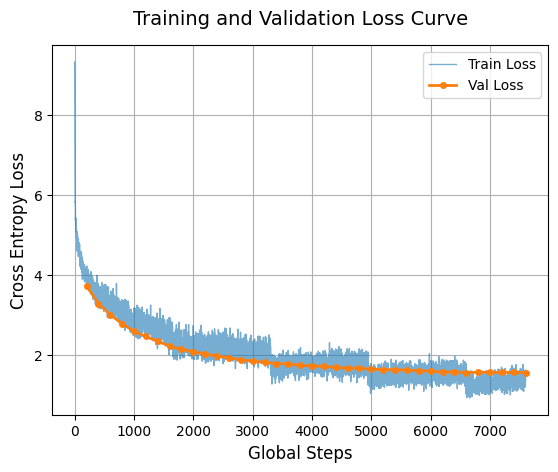

In [30]:
# 提取数据
train_steps = [i["step"] for i in record["train"]]
train_losses = [i["loss"] for i in record["train"]]
val_steps = [i["step"] for i in record["val"]]
val_losses = [i["loss"] for i in record["val"]]

# 绘制训练损失曲线 (使用细线或半透明，因为数据点通常较多)
plt.plot(train_steps, train_losses, label="Train Loss", color='#1f77b4', alpha=0.6, linewidth=1)

# 绘制验证损失曲线 (通常点较少，可以用稍粗的线并加上标记点)
plt.plot(val_steps, val_losses, label="Val Loss", color='#ff7f0e', linewidth=2, marker='o', markersize=4)

# 添加标题和坐标轴名称
plt.title("Training and Validation Loss Curve", fontsize=14, pad=15)
plt.xlabel("Global Steps", fontsize=12)
plt.ylabel("Cross Entropy Loss", fontsize=12)

# 添加图例
plt.legend(loc='upper right', fontsize=10)
plt.grid()
plt.show()

## 推理

将指定路径文件拷贝到当前目录下：cp checkpoints/best.ckpt .

In [ ]:
# load checkpoints,如何上线,本地使用
# 注意此处初始化的模型结构要和训练时的模型结构一样
model = Sequence2Sequence(len(src_word2idx), len(trg_word2idx))
model.load_state_dict(torch.load(f"./checkpoints/best_cloud.ckpt", weights_only=True,map_location="cpu"))  # 加载训练号的模型权重

class Translator:
    def __init__(self, model, src_tokenizer, trg_tokenizer):
        self.model = model
        self.model.eval() # 切换到验证模式
        self.src_tokenizer = src_tokenizer
        self.trg_tokenizer = trg_tokenizer

    def draw_attention_map(self, scores, src_words_list, trg_words_list):
        """
        绘制注意力热力图

        Args:
            - scores (numpy.ndarray): shape = [source sequence length, target sequence length]
        """
        print(scores.shape)  # （pred_seq_len,input_seq_len)
        #scores.T转置后，变为（pred_seq_len,input_seq_len)
        plt.matshow(scores.T, cmap='viridis') # 注意力矩阵,显示注意力分数值

        # 获取当前的轴
        ax = plt.gca()

        # 设置热图中每个单元格的分数的文本
        for i in range(scores.shape[0]): #输入
            for j in range(scores.shape[1]): #输出
                ax.text(i, j, f'{scores[i, j]:.2f}',  # 格式化数字显示
                               ha='center', va='center', color='k')
        print(scores.shape[0])
        print(scores.shape[1])
        plt.xticks(range(scores.shape[0]), src_words_list)  # 横轴设为 src
        plt.yticks(range(scores.shape[1]), trg_words_list)  # 纵轴设为 trg
        plt.show()

    def __call__(self, sentence):
        # 预处理句子，标点符号处理等
        sentence = preprocess_ja(sentence)  # 源语言为日语
        # sentence = preprocess_en(sentence)  # 输入源语言是英语时切换这句

        encoder_input, attn_mask = self.src_tokenizer.encode(
            [sentence.split()],
            padding_first=True,
            add_bos=True,
            add_eos=True,
            return_mask=True,
            ) # 对输入进行编码，并返回encode_piadding_mask
        encoder_input = torch.Tensor(encoder_input).to(dtype=torch.int64) # 转换成tensor

        # 推理预测
        preds, scores = model.infer(encoder_input=encoder_input, attn_mask=attn_mask)

        # 通过 tokenizer 将 id 转换成文字
        # tokenizer.decode 返回的是一个嵌套的二维 list ，list中的每个子 list 代表解码的一句话
        # 此处只传了一句，所以取 list[0] 即获得当前句子 id 转成的 文字 的 list
        trg_sentence = self.trg_tokenizer.decode([preds], split=True, remove_eos=False)[0] 

        # encoder_input 中进行了添加[PAD]、以及词表中不存在的输入词被替换为 [UNK] 等处理
        # 为了保持热力图显示与真实的 模型输入数据一致，对encoder_input再做一次decode得到输入文字而不是直接使用sentence.split()
        src_decoded = self.src_tokenizer.decode(
            encoder_input.tolist(),
            split=True,
            remove_bos=False,
            remove_eos=False
            )[0] #对输入编码id进行解码，转换成文字,为了画图

        # 绘制注意力热力图
        self.draw_attention_map(
            scores.squeeze(0).numpy(),
            src_decoded,  # 注意力图的源句子,文本列表
            trg_sentence  # 注意力图的目标句子，文本列表
            )

        # 将句子中单词以空格拼接，返回
        return " ".join(trg_sentence[:-1]) #-1是EOS，切掉不要




### 测试用例

1. 基础短句 (Basic Sentences)

用于检查模型是否正确学习了最基础的对应关系。

- こんにちは。 (Konnichiwa / Hello.)

- 行け。 (Ike / Go.)

- 誰ですか？ (Dare desu ka / Who is it?)

- 分かりました。 (Wakarimashita / I understand.)

2. 日常表达 (Common Expressions)

测试模型对常用语法结构（如否定、请求）的掌握。

- 私は学生です。 (Watashi wa gakusei desu / I am a student.)

- お腹が空いた。 (Onaka ga suita / I'm hungry.)

- 本を貸してください。 (Hon o kashite kudasai / Please lend me the book.)

- 英語が話せますか？ (Eigo ga hanasemasu ka / Can you speak English?)

3. 注意力机制测试句 (Sentences for Attention Map)

这些句子语序与英语差异较大，可以很好地观察注意力热力图的对齐（Alignment）情况：

- 私はリンゴを食べました。

    (英语语序：Subject - Verb - Object / 日语语序：Subject - Object - Verb)

    预期效果：你会看到热力图中出现交叉点，因为英语的 "ate" 对应日语末尾的 "食べました"。

- 日本に行きたいです。 (I want to go to Japan.)

    预期效果：观察 "きたい" (want to) 是如何映射到英语助动词上的。

(10, 6)
10
6


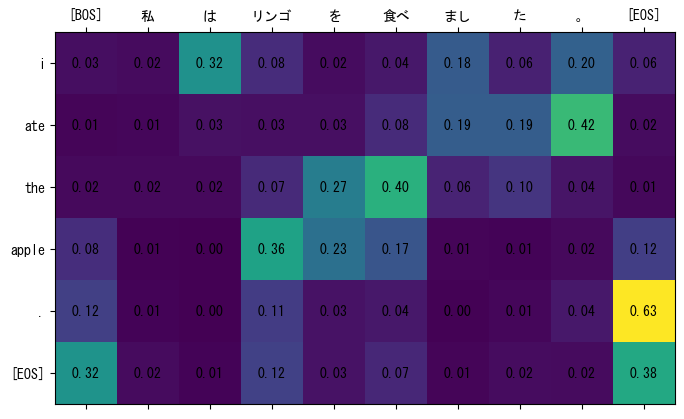

'i ate the apple .'

In [53]:
translator = Translator(model.cpu(), src_tokenizer, trg_tokenizer)
translator('私はリンゴを食べました。')

## 计算BLUE分数

In [ ]:
model = Sequence2Sequence(len(src_word2idx), len(trg_word2idx))
model.load_state_dict(torch.load(f"checkpoints/best_cloud.ckpt", map_location="cpu"))

class Translator:
    def __init__(self, model, src_tokenizer, trg_tokenizer):
        self.model = model
        self.model.eval() # 切换到验证模式
        self.src_tokenizer = src_tokenizer
        self.trg_tokenizer = trg_tokenizer

    def __call__(self, sentence):
        sentence = preprocess_ja(sentence) # 预处理句子，标点符号处理等
        encoder_input, attn_mask = self.src_tokenizer.encode(
            [sentence.split()],
            padding_first=True,
            add_bos=True,
            add_eos=True,
            return_mask=True,
            ) # 对输入进行编码，并返回encode_piadding_mask
        encoder_input = torch.Tensor(encoder_input).to(dtype=torch.int64) # 转换成tensor

        preds, scores = model.infer(encoder_input=encoder_input, attn_mask=attn_mask) #预测

        trg_sentence = self.trg_tokenizer.decode([preds], split=True, remove_eos=False)[0] #通过tokenizer转换成文字

        return " ".join(trg_sentence[:-1])

from nltk.translate.bleu_score import SmoothingFunction, sentence_bleu

def evaluate_bleu_on_test_set(test_data, translator):
    """
    在测试集上计算平均 BLEU 分数。
    :param test_data: 测试集数据，格式为 [(src_sentence, [ref_translation1, ref_translation2, ...]), ...]
    :param translator: 翻译器对象（Translator 类的实例）
    :return: 平均 BLEU 分数
    """
    total_bleu = 0.0
    num_samples = len(test_data)
    i=0
    for src_sentence, ref_translations in test_data:
        # 使用翻译器生成翻译结果
        candidate_translation = translator(src_sentence)
        smooth = SmoothingFunction().method1
        # 计算 BLEU 分数
        bleu_score = sentence_bleu([ref_translations.split()], candidate_translation.split(),weights=(1, 0, 0, 0),smoothing_function=smooth)  # BLEU-1
        total_bleu += bleu_score

        # 打印当前句子的 BLEU 分数（可选）
        # print(f"Source: {src_sentence}")
        # print(f"Reference: {ref_translations}")
        # print(f"Candidate: {candidate_translation}")
        # print(f"BLEU: {bleu_score:.4f}")
        # print("-" * 50)
        # i+=1
        # if i>10:
        #     break
    # 计算平均 BLEU 分数
    avg_bleu = total_bleu / num_samples
    return avg_bleu

# 计算 BLEU-1 分数
translator = Translator(model.cpu(), src_tokenizer, trg_tokenizer)
evaluate_bleu_on_test_set(test_ds, translator)

C:\Users\MSI-NB\AppData\Local\Temp\ipykernel_27328\3036528646.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"checkpoints/best_cloud.c

0.5690527744597583

In [56]:
def evaluate_bleu_on_test_set(test_data, translator):
    """
    在测试集上计算平均 BLEU 分数。
    :param test_data: 测试集数据，格式为 [(src_sentence, [ref_translation1, ref_translation2, ...]), ...]
    :param translator: 翻译器对象（Translator 类的实例）
    :return: 平均 BLEU 分数
    """
    total_bleu = 0.0
    num_samples = len(test_data)
    i=0
    for src_sentence, ref_translations in test_data:
        # 使用翻译器生成翻译结果
        candidate_translation = translator(src_sentence)

        # 计算 BLEU 分数
        bleu_score = sentence_bleu([ref_translations.split()], candidate_translation.split(),weights=(0.25, 0.25, 0.25, 0.25))  # BLEU-4
        total_bleu += bleu_score

        # 打印当前句子的 BLEU 分数（可选）
        # print(f"Source: {src_sentence}")
        # print(f"Reference: {ref_translations}")
        # print(f"Candidate: {candidate_translation}")
        # print(f"BLEU: {bleu_score:.4f}")
        # print("-" * 50)
        # i+=1
        # if i>10:
        #     break
    # 计算平均 BLEU 分数
    avg_bleu = total_bleu / num_samples
    return avg_bleu

# 计算 BLEU-1 分数
translator = Translator(model.cpu(), src_tokenizer, trg_tokenizer)
evaluate_bleu_on_test_set(test_ds, translator)

c:\Users\MSI-NB\AppData\Local\Programs\Python\Python312\Lib\site-packages\nltk\translate\bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
c:\Users\MSI-NB\AppData\Local\Programs\Python\Python312\Lib\site-packages\nltk\translate\bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
c:\Users\MSI-NB\AppData\Local\Programs\Python\Python312\Lib\site-packages\nltk\translate\bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of l

0.21274749618654173